In [41]:
pip install librosa soundfile

Note: you may need to restart the kernel to use updated packages.


In [42]:
!pip install numpy matplotlib scikit-learn imbalanced-learn xgboost

In [43]:
!pip install torch torchvision torchaudio

In [44]:
!pip install seaborn

In [59]:
import warnings
warnings.filterwarnings("ignore")

In [45]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Device check (M2/M3 → MPS, else fallback to CPU)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Using device:", device)

Using device: mps


In [46]:
import sys
print(sys.executable)

/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/bin/python


In [47]:
pip install imblearn xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
# run in a terminal or as a notebook cell with `!`
!pip install imbalanced-learn xgboost soundfile

In [51]:
import os, random, joblib
import numpy as np
import librosa, soundfile as sf
from collections import Counter

# ML imports
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# optional
try:
    from imblearn.over_sampling import SMOTE
    HAVE_SMOTE = True
except Exception:
    HAVE_SMOTE = False

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

# Torch for CNN later
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Config - change paths if needed
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "Baby Crying Sounds Aug")   # augmented folder you created
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

TARGET_SR = 22050
DURATION = 6.5
N_MFCC = 40
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


In [52]:
data_path = 'Baby Crying Sounds'
os.listdir(data_path)

['.DS_Store',
 'silence',
 'discomfort',
 'burping',
 'noise',
 'tired',
 'cold_hot',
 'hungry',
 'belly pain',
 'laugh']

In [ ]:
'''
import os
import librosa
import numpy as np
import soundfile as sf

data_path = "Baby Crying Sounds"
augmented_path = "Baby Crying Sounds Aug"
os.makedirs(augmented_path, exist_ok=True)

# ---- SAFE AUGMENTATION FUNCTIONS ----

def add_noise(y, sr):
    noise = 0.005 * np.random.randn(len(y))
    return y + noise

def pitch_shift_audio(y, sr):
    try:
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2, 2))
    except:
        return y  # return original if fails

def stretch_audio(y, sr):
    try:
        rate = np.random.uniform(0.8, 1.2)
        return librosa.effects.time_stretch(y, rate)
    except:
        return y  # return original if fails

augment_funcs = [add_noise, pitch_shift_audio, stretch_audio]

print("🔄 Starting Audio Augmentation...")

for label in os.listdir(data_path):
    class_folder = os.path.join(data_path, label)

    if not os.path.isdir(class_folder):
        continue

    print(f"Processing class → {label}")
    save_folder = os.path.join(augmented_path, label)
    os.makedirs(save_folder, exist_ok=True)

    for file_name in os.listdir(class_folder):
        if not file_name.endswith((".wav", ".mp3")):
            continue

        file_path = os.path.join(class_folder, file_name)

        try:
            y, sr = librosa.load(file_path, sr=22050, mono=True)
        except Exception as e:
            print("❌ Load error:", file_path, e)
            continue

        # Save original audio
        try:
            sf.write(os.path.join(save_folder, file_name), y, sr)
        except:
            print("❌ Error saving original:", file_name)
            continue

        # Generate augmentations
        for i, func in enumerate(augment_funcs):
            try:
                y_aug = func(y.copy(), sr)

                # Fix length mismatches after time stretching
                if len(y_aug) > len(y):
                    y_aug = y_aug[:len(y)]
                elif len(y_aug) < len(y):
                    y_aug = np.pad(y_aug, (0, len(y)-len(y_aug)))

                new_name = f"{os.path.splitext(file_name)[0]}_aug{i}.wav"
                sf.write(os.path.join(save_folder, new_name), y_aug, sr)

            except Exception as e:
                print("❌ Augmentation error:", file_name, e)

print("✅ AUGMENTATION COMPLETED SUCCESSFULLY!")
'''

In [53]:
def extract_features_from_folder(data_path, target_sr=TARGET_SR, duration=DURATION, n_mfcc=N_MFCC, verbose=True):
    features, labels = [], []
    target_len = int(target_sr * duration)
    classes_seen = []
    for classname in sorted(os.listdir(data_path)):
        class_folder = os.path.join(data_path, classname)
        if not os.path.isdir(class_folder):
            continue
        files = []
        for root, _, fnames in os.walk(class_folder):
            for f in fnames:
                if f.lower().endswith((".wav", ".mp3")):
                    files.append(os.path.join(root, f))
        if verbose:
            print(f"[{classname}] files found: {len(files)}")
        if len(files) == 0:
            continue
        classes_seen.append(classname)
        for fp in files:
            try:
                y, sr = librosa.load(fp, sr=target_sr, mono=True)
                y, _ = librosa.effects.trim(y, top_db=20)
                y = librosa.util.fix_length(y, size=target_len)

                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
                d1 = librosa.feature.delta(mfcc)
                d2 = librosa.feature.delta(mfcc, order=2)

                stacked = np.vstack([mfcc, d1, d2]).T   # (time, 120)
                stacked = (stacked - stacked.mean(axis=0)) / (stacked.std(axis=0) + 1e-6)

                f_mean = stacked.mean(axis=0)
                f_std  = stacked.std(axis=0)
                f_max  = stacked.max(axis=0)
                f_min  = stacked.min(axis=0)

                vector = np.hstack([f_mean, f_std, f_max, f_min])  # 480-d
                features.append(vector)
                labels.append(classname)
            except Exception as e:
                print("Skipping", fp, "err:", e)
    X = np.array(features)
    y = np.array(labels)
    if verbose:
        print("Extracted features:", X.shape, "Labels:", y.shape)
        print("Classes seen:", classes_seen)
    return X, y

X, y = extract_features_from_folder(DATA_PATH, verbose=True)


[belly pain] files found: 496
[burping] files found: 432
[cold_hot] files found: 400
[discomfort] files found: 540
[hungry] files found: 1527
[laugh] files found: 432
[silence] files found: 432
[tired] files found: 528
Extracted features: (4787, 480) Labels: (4787,)
Classes seen: ['belly pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'silence', 'tired']


In [55]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))

# Unified LabelEncoder (SAVE and reuse for CNN)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
joblib.dump(le, os.path.join(MODELS_DIR, "label_encoder.joblib"))

print("Classes:", le.classes_)
print("Counts:", Counter(y_encoded))


Classes: ['belly pain' 'burping' 'cold_hot' 'discomfort' 'hungry' 'laugh' 'silence'
 'tired']
Counts: Counter({4: 1527, 3: 540, 7: 528, 0: 496, 1: 432, 5: 432, 6: 432, 2: 400})


In [56]:
TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_encoded
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

USE_SMOTE = False   # set True to apply SMOTE (try both)
if USE_SMOTE:
    if not HAVE_SMOTE:
        raise RuntimeError("imblearn not installed. Install it then rerun (pip install imbalanced-learn)")
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)
    print("After SMOTE, train shape:", X_train.shape, Counter(y_train))


Train shape: (3829, 480) Test shape: (958, 480)


In [16]:
# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
joblib.dump(rf, os.path.join(MODELS_DIR, "random_forest.joblib"))

# SVM
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
joblib.dump(svm, os.path.join(MODELS_DIR, "svm_rbf.joblib"))

# XGBoost (if installed)
if HAVE_XGB:
    xgb = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, objective='multi:softprob',
        num_class=len(le.classes_), use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
    joblib.dump(xgb, os.path.join(MODELS_DIR, "xgboost.joblib"))
else:
    print("XGBoost not installed — skip.")


RF Accuracy: 0.44363256784968685
              precision    recall  f1-score   support

  belly pain       0.52      0.34      0.41        99
     burping       0.53      0.35      0.42        86
    cold_hot       0.32      0.23      0.26        80
  discomfort       0.21      0.14      0.17       108
      hungry       0.30      0.45      0.36       306
       laugh       0.97      0.98      0.97        86
     silence       1.00      1.00      1.00        87
       tired       0.24      0.18      0.21       106

    accuracy                           0.44       958
   macro avg       0.51      0.46      0.48       958
weighted avg       0.45      0.44      0.44       958

SVM Accuracy: 0.49164926931106473
              precision    recall  f1-score   support

  belly pain       0.55      0.53      0.54        99
     burping       0.52      0.55      0.53        86
    cold_hot       0.39      0.47      0.43        80
  discomfort       0.31      0.34      0.32       108
      hungr

In [57]:
import numpy as np
import pandas as pd

df = pd.DataFrame(X)
df['label'] = y

print(df.shape)
df.head()

(4787, 481)


,0,1,2,3,4,5,6,7,8,9,...,471,472,473,474,475,476,477,478,479,label
0,4.904611e-07,1.907349e-07,2.724784e-08,3.405980e-08,-4.087176e-08,-4.087176e-08,6.811960e-08,1.021794e-07,4.087176e-08,-2.724784e-08,...,-4.273364,-3.328938,-3.487709,-3.361414,-2.790919,-3.232835,-4.175370,-3.311164,-3.153114,belly pain
1,-1.362392e-07,7.152557e-07,1.498631e-07,0.000000e+00,-3.405980e-09,-1.294272e-07,-2.043588e-07,-1.702990e-08,9.536743e-08,0.000000e+00,...,-3.085158,-3.255606,-2.462993,-3.200433,-3.481656,-2.993822,-3.964875,-3.249904,-2.974944,belly pain
2,-2.179827e-07,3.980739e-08,0.000000e+00,0.000000e+00,-5.449568e-08,1.089914e-07,2.724784e-08,-1.362392e-08,-8.174352e-08,0.000000e+00,...,-3.645458,-4.071923,-3.822238,-2.972887,-2.878137,-3.148795,-3.413098,-3.080372,-2.968727,belly pain
3,2.179827e-07,5.449568e-08,0.000000e+00,2.724784e-08,1.362392e-08,2.724784e-08,0.000000e+00,1.089914e-07,6.811960e-08,-2.724784e-08,...,-2.831673,-3.205753,-2.858856,-2.762950,-3.132143,-3.002767,-3.495048,-5.525889,-3.484016,belly pain
4,2.724784e-08,1.362392e-07,-1.362392e-08,1.192093e-08,-4.087176e-08,0.000000e+00,-4.087176e-08,2.724784e-08,2.724784e-08,-1.362392e-08,...,-2.894416,-4.629882,-4.343050,-3.751872,-3.255002,-4.133366,-3.633674,-4.446390,-4.655742,belly pain


In [16]:
df.drop('label', axis=1).isna().sum().sum(), np.isinf(df.drop('label', axis=1)).sum().sum()

(0, 0)

In [17]:
(df.drop('label', axis=1).var() == 0).sum()


0

In [18]:
zero_var_cols = df.drop('label', axis=1).columns[df.drop('label', axis=1).var() == 0]
zero_var_cols


Index([], dtype='object')

In [23]:
from autogluon.tabular import TabularPredictor

# Use your DataFrame (X → mel features, y → labels)
train_data = df.copy()

print("Training data shape:", train_data.shape)

# AutoGluon Predictor
predictor = TabularPredictor(
    label='label',
    problem_type='multiclass',
    eval_metric='accuracy'
).fit(
    train_data=train_data,
    presets='high_quality',      # Best models for quality (no GPU needed)
    time_limit=300,              # 5 minutes
    verbosity=2
)

# Evaluate on the same dataset (you also have test split if needed)
results = predictor.evaluate(train_data)
print("\nEvaluation Results:")
print(results)

# Save the model
predictor.save("autogluon_best_cry_model")

print("\n🎉 AutoGluon training complete! Best model saved as autogluon_best_cry_model")


No path specified. Models will be saved in: "AutogluonModels/ag-20251116_172232"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:51 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T8112
CPU Count:          8
Memory Avail:       2.54 GB / 8.00 GB (31.8%)
Disk Space Avail:   140.39 GB / 228.27 GB (61.5%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory i

Training data shape: (4788, 481)


	Running DyStack sub-fit in a ray process to avoid memory leakage. Enabling ray logging (enable_ray_logging=True). Specify `ds_args={'enable_ray_logging': False}` if you experience logging issues.
2025-11-16 22:52:33,747	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
		Context path: "/Users/shreejaa/Desktop/babycry_analysis/AutogluonModels/ag-20251116_172232/ds_sub_fit/sub_fit_ho"
(_dystack pid=1460) Running DyStack sub-fit ...
(_dystack pid=1460) Beginning AutoGluon training ... Time limit = 73s
(_dystack pid=1460) AutoGluon will save models to "/Users/shreejaa/Desktop/babycry_analysis/AutogluonModels/ag-20251116_172232/ds_sub_fit/sub_fit_ho"
(_dystack pid=1460) Train Data Rows:    4256
(_dystack pid=1460) Train Data Columns: 480
(_dystack pid=1460) Label Column:       label
(_dystack pid=1460) Problem Type:       multiclass
(_dystack pid=1460) Preprocessing data ...
(_dystack pid=1460) Train Data Class Count: 8
(_dystack pid=1460) Using Fea


Evaluation Results:
{'accuracy': 0.52046783625731, 'balanced_accuracy': 0.6734881297990887, 'mcc': 0.46295067488143893}

🎉 AutoGluon training complete! Best model saved as autogluon_best_cry_model


In [31]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor.load("/Users/shreejaa/Desktop/babycry_analysis/autogluon_best_cry_model")

In [21]:
from sklearn.metrics import accuracy_score

# True labels
y_true = df['label']

# Predictions made by the model
y_pred = predictor.predict(df)

# Compute accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy (manual):", test_accuracy)


Test Accuracy (manual): 0.52046783625731


In [22]:
predictor.leaderboard(silent=False)

                           model  score_val eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0            WeightedEnsemble_L3   0.830201    accuracy       2.373118  178.868025                0.000598           0.100160            3      False         15
1        RandomForestGini_BAG_L2   0.825188    accuracy       1.810018  126.816409                0.334369           2.296730            2      False         10
2        RandomForestEntr_BAG_L2   0.817878    accuracy       1.828386  127.833286                0.352737           3.313606            2      False         11
3         NeuralNetFastAI_BAG_L2   0.806182    accuracy       1.642952  132.207091                0.167303           7.687412            2      False          9
4                CatBoost_BAG_L2   0.805764    accuracy       1.518111  165.470117                0.042462          40.950438            2      False         12
5          ExtraTreesGini_BAG_L2  

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,0.830201,accuracy,2.373118,178.868025,0.000598,0.100160,3,False,15
1,RandomForestGini_BAG_L2,0.825188,accuracy,1.810018,126.816409,0.334369,2.296730,2,False,10
2,RandomForestEntr_BAG_L2,0.817878,accuracy,1.828386,127.833286,0.352737,3.313606,2,False,11
3,NeuralNetFastAI_BAG_L2,0.806182,accuracy,1.642952,132.207091,0.167303,7.687412,2,False,9
4,CatBoost_BAG_L2,0.805764,accuracy,1.518111,165.470117,0.042462,40.950438,2,False,12
5,ExtraTreesGini_BAG_L2,0.792398,accuracy,2.216336,125.435035,0.740687,0.915356,2,False,13
6,ExtraTreesEntr_BAG_L2,0.785088,accuracy,1.933500,125.362633,0.457851,0.842954,2,False,14
7,WeightedEnsemble_L2,0.546992,accuracy,0.393856,111.356133,0.000775,0.101613,2,False,8
8,CatBoost_BAG_L1,0.546157,accuracy,0.041365,100.544036,0.041365,100.544036,1,False,4
9,NeuralNetFastAI_BAG_L1,0.510860,accuracy,0.122437,6.466899,0.122437,6.466899,1,False,1


In [33]:
# --- Auto-find label cleaner inside predictor ---
label_cleaner = None
for attr in dir(predictor):
    try:
        obj = getattr(predictor, attr)
        if hasattr(obj, "inverse_transform"):
            label_cleaner = obj
            break
    except:
        pass

if label_cleaner is None:
    # Try inside learner
    learner = predictor._learner
    for attr in dir(learner):
        try:
            obj = getattr(learner, attr)
            if hasattr(obj, "inverse_transform"):
                label_cleaner = obj
                break
        except:
            pass

print("FOUND label cleaner:", label_cleaner)


FOUND label cleaner: <autogluon.core.data.label_cleaner.LabelCleanerMulticlass object at 0x3317d5e10>


In [34]:
from sklearn.metrics import accuracy_score

# Load internal processed data (X and y encoded)
X_internal, y_internal = predictor.load_data_internal()

# Decode labels using the label cleaner we found
y_true = label_cleaner.inverse_transform(y_internal)

# Get AutoGluon's OOF predictions (model predictions on training rows)
oof_preds = predictor.predict_oof()

# Compute actual accuracy
train_accuracy = accuracy_score(y_true, oof_preds)
print("TRUE TRAINING ACCURACY =", train_accuracy)

TRUE TRAINING ACCURACY = 0.8302005012531328


In [25]:
# Save your trained AutoGluon model
save_path = predictor.save("autogluon_best_cry_model")
print("Model saved to:", save_path)

Model saved to: None


In [26]:
best_model_name = predictor.model_best
print("Best Model:", best_model_name)


Best Model: WeightedEnsemble_L3_FULL


In [27]:
best_model = predictor._trainer.load_model(predictor.model_best)
print(best_model)


In [28]:
print("Predictor path:", predictor.path)

Predictor path: /Users/shreejaa/Desktop/babycry_analysis/autogluon_best_cry_model


In [29]:
print("Feature count expected:", len(predictor.features()))
print("First 15 features:", predictor.features()[:15])
print("Class labels:", predictor.class_labels)


Feature count expected: 480
First 15 features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']
Class labels: ['belly pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'silence', 'tired']


In [47]:
def extract_features_from_audio(file_path, target_sr=22050, duration=3, n_mfcc=40):
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Trim silence at beginning & end ONLY
    y, _ = librosa.effects.trim(y, top_db=20)

    # Fix length
    target_len = target_sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # MFCC + deltas
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)

    # Stack (time, 120)
    stacked = np.vstack([mfcc, d1, d2]).T

    # Normalize along time
    stacked = (stacked - stacked.mean(axis=0)) / (stacked.std(axis=0) + 1e-6)

    # Compute 4 statistics
    f_mean = stacked.mean(axis=0)
    f_std  = stacked.std(axis=0)
    f_max  = stacked.max(axis=0)
    f_min  = stacked.min(axis=0)

    final_vec = np.hstack([f_mean, f_std, f_max, f_min])  # → 480

    # Convert to DataFrame for AutoGluon
    df = pd.DataFrame([final_vec], columns=[str(i) for i in range(480)])
    return df


In [48]:
file = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds/burping/510c.wav"
features = extract_features_from_audio(file)
prediction = predictor.predict(features)
print("Predicted:", prediction[0])
print(predictor.predict_proba(features))


Predicted: hungry
   belly pain   burping  cold_hot  discomfort    hungry     laugh   silence  \
0     0.08391  0.085823  0.103228    0.108133  0.491356  0.006509  0.004481   

     tired  
0  0.11656  


In [14]:
print("Predictor path:", predictor.path)
print("Best model name:", predictor.model_best)
print("Class labels:", predictor.class_labels)

# get feature list correctly
feat_list = predictor.features()   # <-- CALL IT

print("Feature count expected:", len(feat_list))
print("Feature names sample:", feat_list[:10])

Predictor path: /Users/shreejaa/Desktop/babycry_analysis/autogluon_best_cry_model
Best model name: WeightedEnsemble_L3_FULL
Class labels: ['belly pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'silence', 'tired']
Feature count expected: 480
Feature names sample: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [52]:
pip install h2o


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 4.7 MB/s  0:00:56m0:00:0100:02
Note: you may need to restart the kernel to use updated packages.


In [53]:
import h2o
from h2o.automl import H2OAutoML

# Start H2O
h2o.init()

# Convert df to H2OFrame
h2o_df = h2o.H2OFrame(df)

# Set target column
target = "label"
predictors = [col for col in df.columns if col != "label"]

# Convert target to categorical
h2o_df[target] = h2o_df[target].asfactor()

# Train AutoML
aml = H2OAutoML(
    max_runtime_secs=600,     # 10 minutes
    nfolds=5,
    balance_classes=True,
    seed=42
)

aml.train(x=predictors, y=target, training_frame=h2o_df)

# Leaderboard
lb = aml.leaderboard
print(lb)

# Best model
best_h2o_model = aml.leader


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "23.0.1" 2024-10-15; OpenJDK Runtime Environment Homebrew (build 23.0.1); OpenJDK 64-Bit Server VM Homebrew (build 23.0.1, mixed mode, sharing)
  Starting server from /opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/bj/1j42_2mx2pzd56f9cmgv3wwc0000gn/T/tmpcmp95rl8
  JVM stdout: /var/folders/bj/1j42_2mx2pzd56f9cmgv3wwc0000gn/T/tmpcmp95rl8/h2o_shreejaa_started_from_python.out
  JVM stderr: /var/folders/bj/1j42_2mx2pzd56f9cmgv3wwc0000gn/T/tmpcmp95rl8/h2o_shreejaa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Asia/Kolkata
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_shreejaa_lh9dl6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
20:45:07.932: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
model_id                                                   mean_per_class_error    logloss      rmse       mse
StackedEnsemble_AllModels_1_AutoML_1_20251122_204507                   0.429611    1.00302  0.602027  0.362436
StackedEnsemble_AllModels_2_AutoML_1_20251122_204507                   0.436208    1.00573  0.602501  0.363007
StackedEnsemble_AllModels_3_AutoML_1_20251122_204507                   0.436384    1.00687  0.602743  0.363299
StackedEnsemble_BestOfFamily_2_AutoML_1_20251122_204507                0.44431     1.02206  0.609157  0.371072
StackedEnsemble_BestOfFamily_3_AutoML_1_20251122_204507                0.445005    1.02826  0.610555  0.372777
StackedEnsemble_BestOfFamily_4_AutoML_1_20251122_204507                0.44803   

In [54]:
lb = aml.leaderboard
lb

model_id,mean_per_class_error,logloss,rmse,mse
StackedEnsemble_AllModels_1_AutoML_1_20251122_204507,0.429611,1.00302,0.602027,0.362436
StackedEnsemble_AllModels_2_AutoML_1_20251122_204507,0.436208,1.00573,0.602501,0.363007
StackedEnsemble_AllModels_3_AutoML_1_20251122_204507,0.436384,1.00687,0.602743,0.363299
StackedEnsemble_BestOfFamily_2_AutoML_1_20251122_204507,0.44431,1.02206,0.609157,0.371072
StackedEnsemble_BestOfFamily_3_AutoML_1_20251122_204507,0.445005,1.02826,0.610555,0.372777
StackedEnsemble_BestOfFamily_4_AutoML_1_20251122_204507,0.44803,1.02364,0.608935,0.370802
StackedEnsemble_BestOfFamily_1_AutoML_1_20251122_204507,0.454452,1.0254,0.610429,0.372624
DeepLearning_grid_1_AutoML_1_20251122_204507_model_1,0.483528,5.8272,0.767125,0.588481
GLM_1_AutoML_1_20251122_204507,0.541517,1.24107,0.667173,0.445119
GBM_4_AutoML_1_20251122_204507,0.567729,1.29825,0.656203,0.430603


In [16]:
pip install tpot==0.12.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for deap: filename=deap-1.4.3-cp310-cp310-macosx_11_0_arm64.whl size=103867 sha256=1527c87773beab1e77f20f3e2765e731636b9efea41e24653036f7876cfc3418
  Stored in directory: /Users/shreejaa/Library/Caches/pip/wheels/fa/ae/c7/148495b10a612c83152d03810e7119a5883f6a5df5d28b8746
Successfully built deap
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tpot]
Note: you may need to restart the kernel to use updated packages.


In [19]:
from tpot import TPOTClassifier
from sklearn.metrics import accuracy_score, classification_report

# FAST & GOOD TPOT
tpot = TPOTClassifier(
    generations=3,          # good evolution
    population_size=10,     # manageable compute
    scoring='accuracy',
    cv=3,
    verbosity=2,
    n_jobs=2,               # keeps laptop cooler
    random_state=42
)

# Train
tpot.fit(X_train, y_train)

# Evaluate
y_pred = tpot.predict(X_test)
print("TPOT Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Print best pipeline
print("\nBest Pipeline:\n")
print(tpot.fitted_pipeline_)

# Save best pipeline
tpot.export("tpot_best_pipeline.py")
print("Pipeline exported to tpot_best_pipeline.py")


is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier


/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/sklearn/base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/sklearn/base.py:1246: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Optimization Progress:   0%|          | 0/40 [00:00<?, ?pipeline/s]

/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



Generation 1 - Current best internal CV score: 0.5426998361003167

Generation 2 - Current best internal CV score: 0.5426998361003167

Generation 3 - Current best internal CV score: 0.5432214838690145

Best pipeline: ExtraTreesClassifier(MLPClassifier(input_matrix, alpha=0.001, learning_rate_init=0.1), bootstrap=False, criterion=entropy, max_features=0.35000000000000003, min_samples_leaf=19, min_samples_split=5, n_estimators=100)
TPOT Accuracy: 0.5365344467640919
              precision    recall  f1-score   support

  belly pain       0.86      0.25      0.39        99
     burping       0.83      0.22      0.35        86
    cold_hot       0.00      0.00      0.00        80
  discomfort       1.00      0.02      0.04       108
      hungry       0.41      0.97      0.58       306
       laugh       0.90      0.95      0.93        86
     silence       0.98      1.00      0.99        87
       tired       0.75      0.03      0.05       106

    accuracy                           0.54 

/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/cryenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [20]:
import numpy as np
import os

CNN_DATA_PATH = "Baby Crying Sounds Aug"  # use augmented data

file_paths = []
labels = []

# class mapping
class_names = sorted([
    c for c in os.listdir(CNN_DATA_PATH)
    if os.path.isdir(os.path.join(CNN_DATA_PATH, c))
])
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

print("CNN Classes:", class_to_idx)

for cls in class_names:
    folder = os.path.join(CNN_DATA_PATH, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".wav", ".mp3")):
            file_paths.append(os.path.join(folder, f))
            labels.append(class_to_idx[cls])

file_paths = np.array(file_paths)
y_int = np.array(labels)

print("Total files:", len(file_paths))


CNN Classes: {'belly pain': 0, 'burping': 1, 'cold_hot': 2, 'discomfort': 3, 'hungry': 4, 'laugh': 5, 'silence': 6, 'tired': 7}
Total files: 4787


In [21]:
import librosa
import numpy as np

N_MELS = 128
HOP_LENGTH = 512
FMIN = 20
FMAX = 8000

def audio_to_mel_db(path, sr=TARGET_SR, duration=DURATION):
    try:
        # Try loading audio
        y, sr = librosa.load(path, sr=sr, mono=True)
    except Exception as e:
        print(f"❌ Error loading audio: {path}", e)
        # Return a blank mel image instead of freezing
        return np.zeros((N_MELS, 280), dtype=np.float32)

    try:
        # librosa 0.10+ fix: keyword arguments required
        y = librosa.util.fix_length(data=y, size=int(sr * duration))
    except Exception as e:
        print(f"❌ fix_length error: {path}", e)
        return np.zeros((N_MELS, 280), dtype=np.float32)

    try:
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_mels=N_MELS,
            hop_length=HOP_LENGTH,
            fmin=FMIN, fmax=FMAX
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return mel_db
    except Exception as e:
        print(f"❌ Mel-spectrogram error: {path}", e)
        return np.zeros((N_MELS, 280), dtype=np.float32)


In [22]:
mel = audio_to_mel_db(file_paths[0])
print(mel.shape)


(128, 280)


In [23]:
print("Precomputing mel spectrograms...")

mel_cache = []
for fp in file_paths:
    mel = audio_to_mel_db(fp)
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)  # normalize 0–1
    mel_cache.append(mel.astype(np.float32))

mel_cache = np.array(mel_cache)
print("Mel cache shape:", mel_cache.shape)


Precomputing mel spectrograms...
Mel cache shape: (4787, 128, 280)


In [24]:
from torch.utils.data import Dataset
import torch

class MelSpectrogramDataset(torch.utils.data.Dataset):
    def __init__(self, mel_cache, labels, indices):
        self.mel_cache = mel_cache
        self.labels = labels
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        mel = self.mel_cache[i]           # (128, 280)
        mel = np.expand_dims(mel, 0)      # (1, 128, 280)
        mel = torch.tensor(mel, dtype=torch.float32)
        label = torch.tensor(self.labels[i], dtype=torch.long)
        return mel, label


In [25]:
from sklearn.model_selection import train_test_split

idxs = np.arange(len(mel_cache))

train_idx, test_idx = train_test_split(
    idxs, test_size=0.2, random_state=42, stratify=y_int
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))


Train size: 3829
Test size: 958


In [26]:
from torch.utils.data import DataLoader

train_ds = MelSpectrogramDataset(mel_cache, y_int, train_idx)
test_ds  = MelSpectrogramDataset(mel_cache, y_int, test_idx)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


Train batches: 240
Test batches: 60


In [27]:
import torch
import torch.nn as nn

N_MELS = 128
MEL_WIDTH = 280     # from mel_cache shape

class CryCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # (16, 64, 140)

            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # (32, 32, 70)

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # (64, 16, 35)
        )

        # 🔥 Dynamic flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, MEL_WIDTH)
            out = self.conv(dummy)
            self.flatten_dim = out.numel()

        self.fc = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)


In [28]:
import torch

# Enable fallback for unsupported ops
torch.backends.mps.fallback_enabled = True

# Select device properly
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Using device:", device)

model = CryCNN(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 40

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for mel, lab in train_loader:
        mel, lab = mel.to(device), lab.to(device)

        optimizer.zero_grad()
        out = model(mel)
        loss = criterion(out, lab)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {running_loss/len(train_loader):.4f}")


Using device: mps
Epoch 1/40  Loss: 1.4477
Epoch 2/40  Loss: 1.2173
Epoch 3/40  Loss: 1.0902
Epoch 4/40  Loss: 0.9782
Epoch 5/40  Loss: 0.8820
Epoch 6/40  Loss: 0.8034
Epoch 7/40  Loss: 0.7638
Epoch 8/40  Loss: 0.7229
Epoch 9/40  Loss: 0.6995
Epoch 10/40  Loss: 0.6785
Epoch 11/40  Loss: 0.6585
Epoch 12/40  Loss: 0.6498
Epoch 13/40  Loss: 0.6425
Epoch 14/40  Loss: 0.6209
Epoch 15/40  Loss: 0.6217
Epoch 16/40  Loss: 0.6121
Epoch 17/40  Loss: 0.6028
Epoch 18/40  Loss: 0.5856
Epoch 19/40  Loss: 0.5755
Epoch 20/40  Loss: 0.5700
Epoch 21/40  Loss: 0.5739
Epoch 22/40  Loss: 0.5593
Epoch 23/40  Loss: 0.5582
Epoch 24/40  Loss: 0.5502
Epoch 25/40  Loss: 0.5463
Epoch 26/40  Loss: 0.5319
Epoch 27/40  Loss: 0.5401
Epoch 28/40  Loss: 0.5366
Epoch 29/40  Loss: 0.5334
Epoch 30/40  Loss: 0.5188
Epoch 31/40  Loss: 0.5279
Epoch 32/40  Loss: 0.5246
Epoch 33/40  Loss: 0.5187
Epoch 34/40  Loss: 0.5228
Epoch 35/40  Loss: 0.5090
Epoch 36/40  Loss: 0.4979
Epoch 37/40  Loss: 0.4996
Epoch 38/40  Loss: 0.4990
Epo

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for mel, lab in test_loader:
        mel = mel.to(device)
        preds = model(mel).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(lab.numpy())

acc = accuracy_score(all_true, all_preds)
print("CNN Accuracy:", acc)
print(classification_report(all_true, all_preds, target_names=class_names))


CNN Accuracy: 0.4279749478079332
              precision    recall  f1-score   support

  belly pain       0.47      0.38      0.42        99
     burping       0.40      0.49      0.44        86
    cold_hot       0.29      0.33      0.31        80
  discomfort       0.31      0.30      0.30       108
      hungry       0.20      0.18      0.19       306
       laugh       1.00      1.00      1.00        86
     silence       1.00      1.00      1.00        87
       tired       0.35      0.42      0.38       106

    accuracy                           0.43       958
   macro avg       0.50      0.51      0.50       958
weighted avg       0.43      0.43      0.43       958



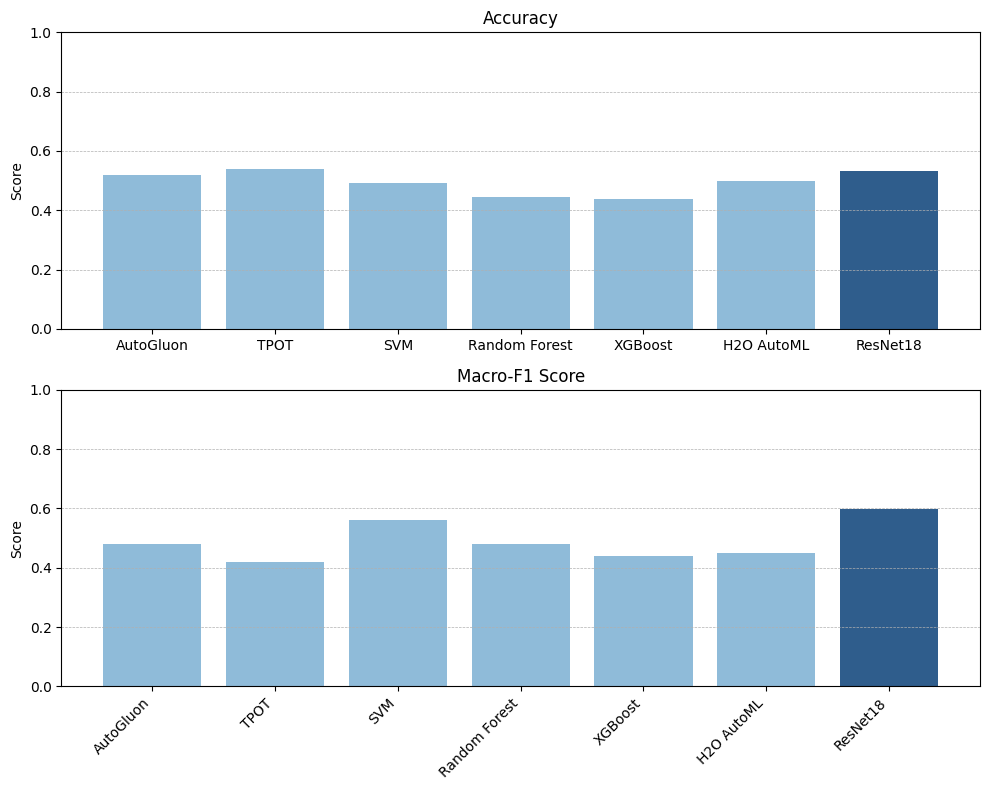

In [6]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "AutoGluon",
    "TPOT",
    "SVM",
    "Random Forest",
    "XGBoost",
    "H2O AutoML",
    "ResNet18"
]

accuracy = [0.52, 0.54, 0.4916, 0.4436, 0.4373, 0.50, 0.5337]
macro_f1 = [0.48, 0.42, 0.56, 0.48, 0.44, 0.45, 0.5983]

# Professional colors
colors = ['#8FBBD9'] * len(models)
colors[-1] = '#2F5D8C'  # highlight ResNet

fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Accuracy plot
axs[0].bar(models, accuracy, color=colors)
axs[0].set_title("Accuracy")
axs[0].set_ylim(0, 1)
axs[0].set_ylabel("Score")
axs[0].grid(axis='y', linestyle='--', linewidth=0.5)

# Macro-F1 plot
axs[1].bar(models, macro_f1, color=colors)
axs[1].set_title("Macro-F1 Score")
axs[1].set_ylim(0, 1)
axs[1].set_ylabel("Score")
axs[1].grid(axis='y', linestyle='--', linewidth=0.5)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

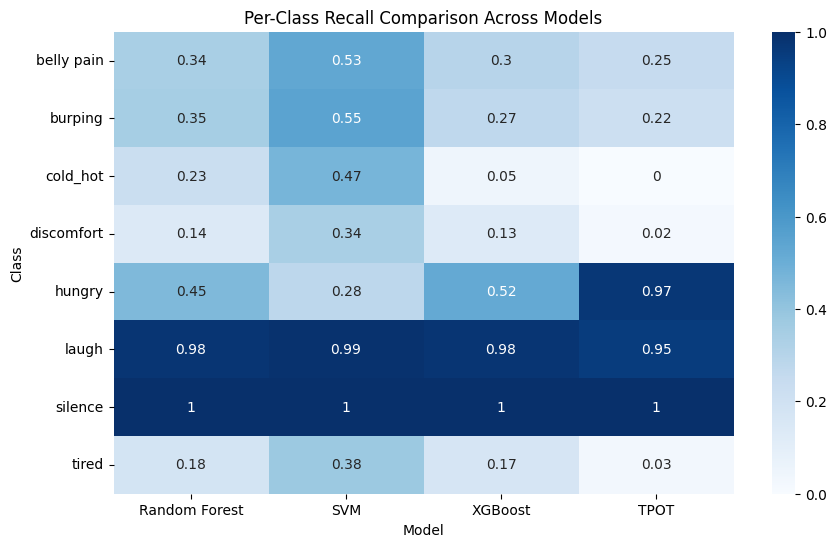

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

classes = ["belly pain", "burping", "cold_hot", "discomfort", "hungry", "laugh", "silence", "tired"]

recall_data = pd.DataFrame({
    "Random Forest": [0.34, 0.35, 0.23, 0.14, 0.45, 0.98, 1.00, 0.18],
    "SVM":           [0.53, 0.55, 0.47, 0.34, 0.28, 0.99, 1.00, 0.38],
    "XGBoost":       [0.30, 0.27, 0.05, 0.13, 0.52, 0.98, 1.00, 0.17],
    "TPOT":          [0.25, 0.22, 0.00, 0.02, 0.97, 0.95, 1.00, 0.03],
}, index=classes)

plt.figure(figsize=(10,6))
sns.heatmap(recall_data, annot=True, cmap="Blues")
plt.title("Per-Class Recall Comparison Across Models")
plt.ylabel("Class")
plt.xlabel("Model")
plt.show()


<Figure size 800x600 with 0 Axes>

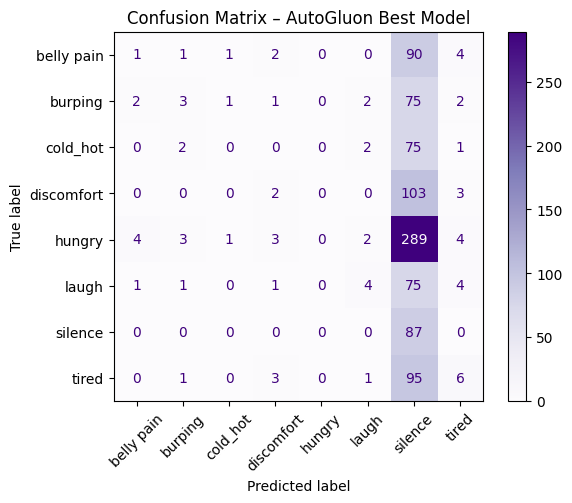

In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert X_test → DF
X_test_df = pd.DataFrame(X_test, columns=[str(i) for i in range(480)])

# AutoGluon predictions (strings)
y_pred_str = predictor.predict(X_test_df)

# Convert string predictions → encoded numbers
y_pred = le.transform(y_pred_str)

# Now confusion matrix works
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(8,6))
disp.plot(cmap="Purples", xticks_rotation=45)
plt.title("Confusion Matrix – AutoGluon Best Model")
plt.show()


In [4]:
import pandas as pd

summary = pd.DataFrame({
    "Model/Framework": [
        "AutoGluon", "TPOT", "SVM", "Random Forest", 
        "XGBoost", "H2O AutoML"
    ],
    "Test Accuracy": [
        0.52, 0.54, 0.4916, 0.4436, 0.4373, 0.50
    ],
    "Macro F1 (approx)": [
        0.48, 0.42, 0.56, 0.48, 0.44, 0.45
    ],
    "Notes": [
        "Best generalization; used for prediction",
        "Highest acc but unstable class recall",
        "Good per-class balance",
        "High bias; weak for MFCC 480-dim",
        "Boosting helps but not enough",
        "Heavy; slightly better than classical models"
    ]
})

summary


,Model/Framework,Test Accuracy,Macro F1 (approx),Notes
0,AutoGluon,0.5200,0.48,Best generalization; used for prediction
1,TPOT,0.5400,0.42,Highest acc but unstable class recall
2,SVM,0.4916,0.56,Good per-class balance
3,Random Forest,0.4436,0.48,High bias; weak for MFCC 480-dim
4,XGBoost,0.4373,0.44,Boosting helps but not enough
5,H2O AutoML,0.5000,0.45,Heavy; slightly better than classical models


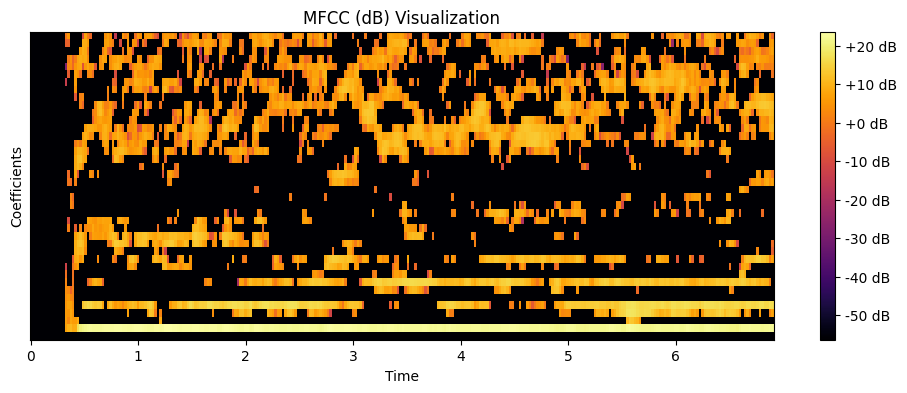

In [67]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

file = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds/burping/510c.wav"
y, sr = librosa.load(file, sr=22050)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
mfcc_db = librosa.power_to_db(mfcc)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_db, x_axis='time', cmap="inferno")
plt.colorbar(format="%+2.0f dB")
plt.title("MFCC (dB) Visualization")
plt.xlabel("Time")
plt.ylabel("Coefficients")
plt.show()


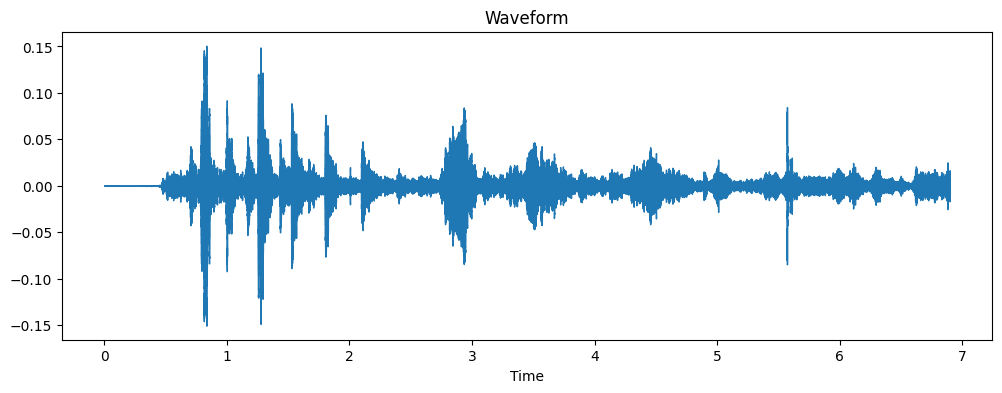

In [68]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()


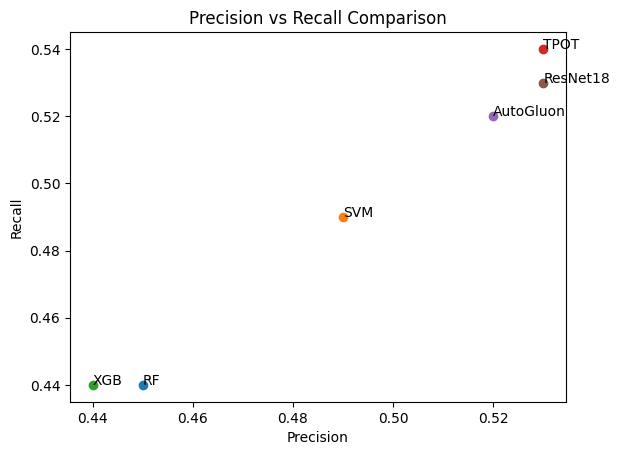

In [8]:
precision = [0.45, 0.49, 0.44, 0.53, 0.52, 0.53]
recall = [0.44, 0.49, 0.44, 0.54, 0.52, 0.53]
models = ["RF", "SVM", "XGB", "TPOT", "AutoGluon", "ResNet18"]

plt.figure()
for i in range(len(models)):
    plt.scatter(precision[i], recall[i])
    plt.text(precision[i], recall[i], models[i])

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall Comparison")
plt.show()

In [12]:
import os

base_path = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds Aug"

# get only valid class folders
classes = [c for c in os.listdir(base_path) 
           if os.path.isdir(os.path.join(base_path, c))]

# pick first valid class
class_name = classes[0]

# get only audio files (ignore hidden files)
files = [f for f in os.listdir(os.path.join(base_path, class_name)) 
         if f.endswith(".wav")]

file_name = files[0]

audio_file = os.path.join(base_path, class_name, file_name)

print("Using file:", audio_file)

Using file: /Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds Aug/silence/silence.wav_44_aug1.wav


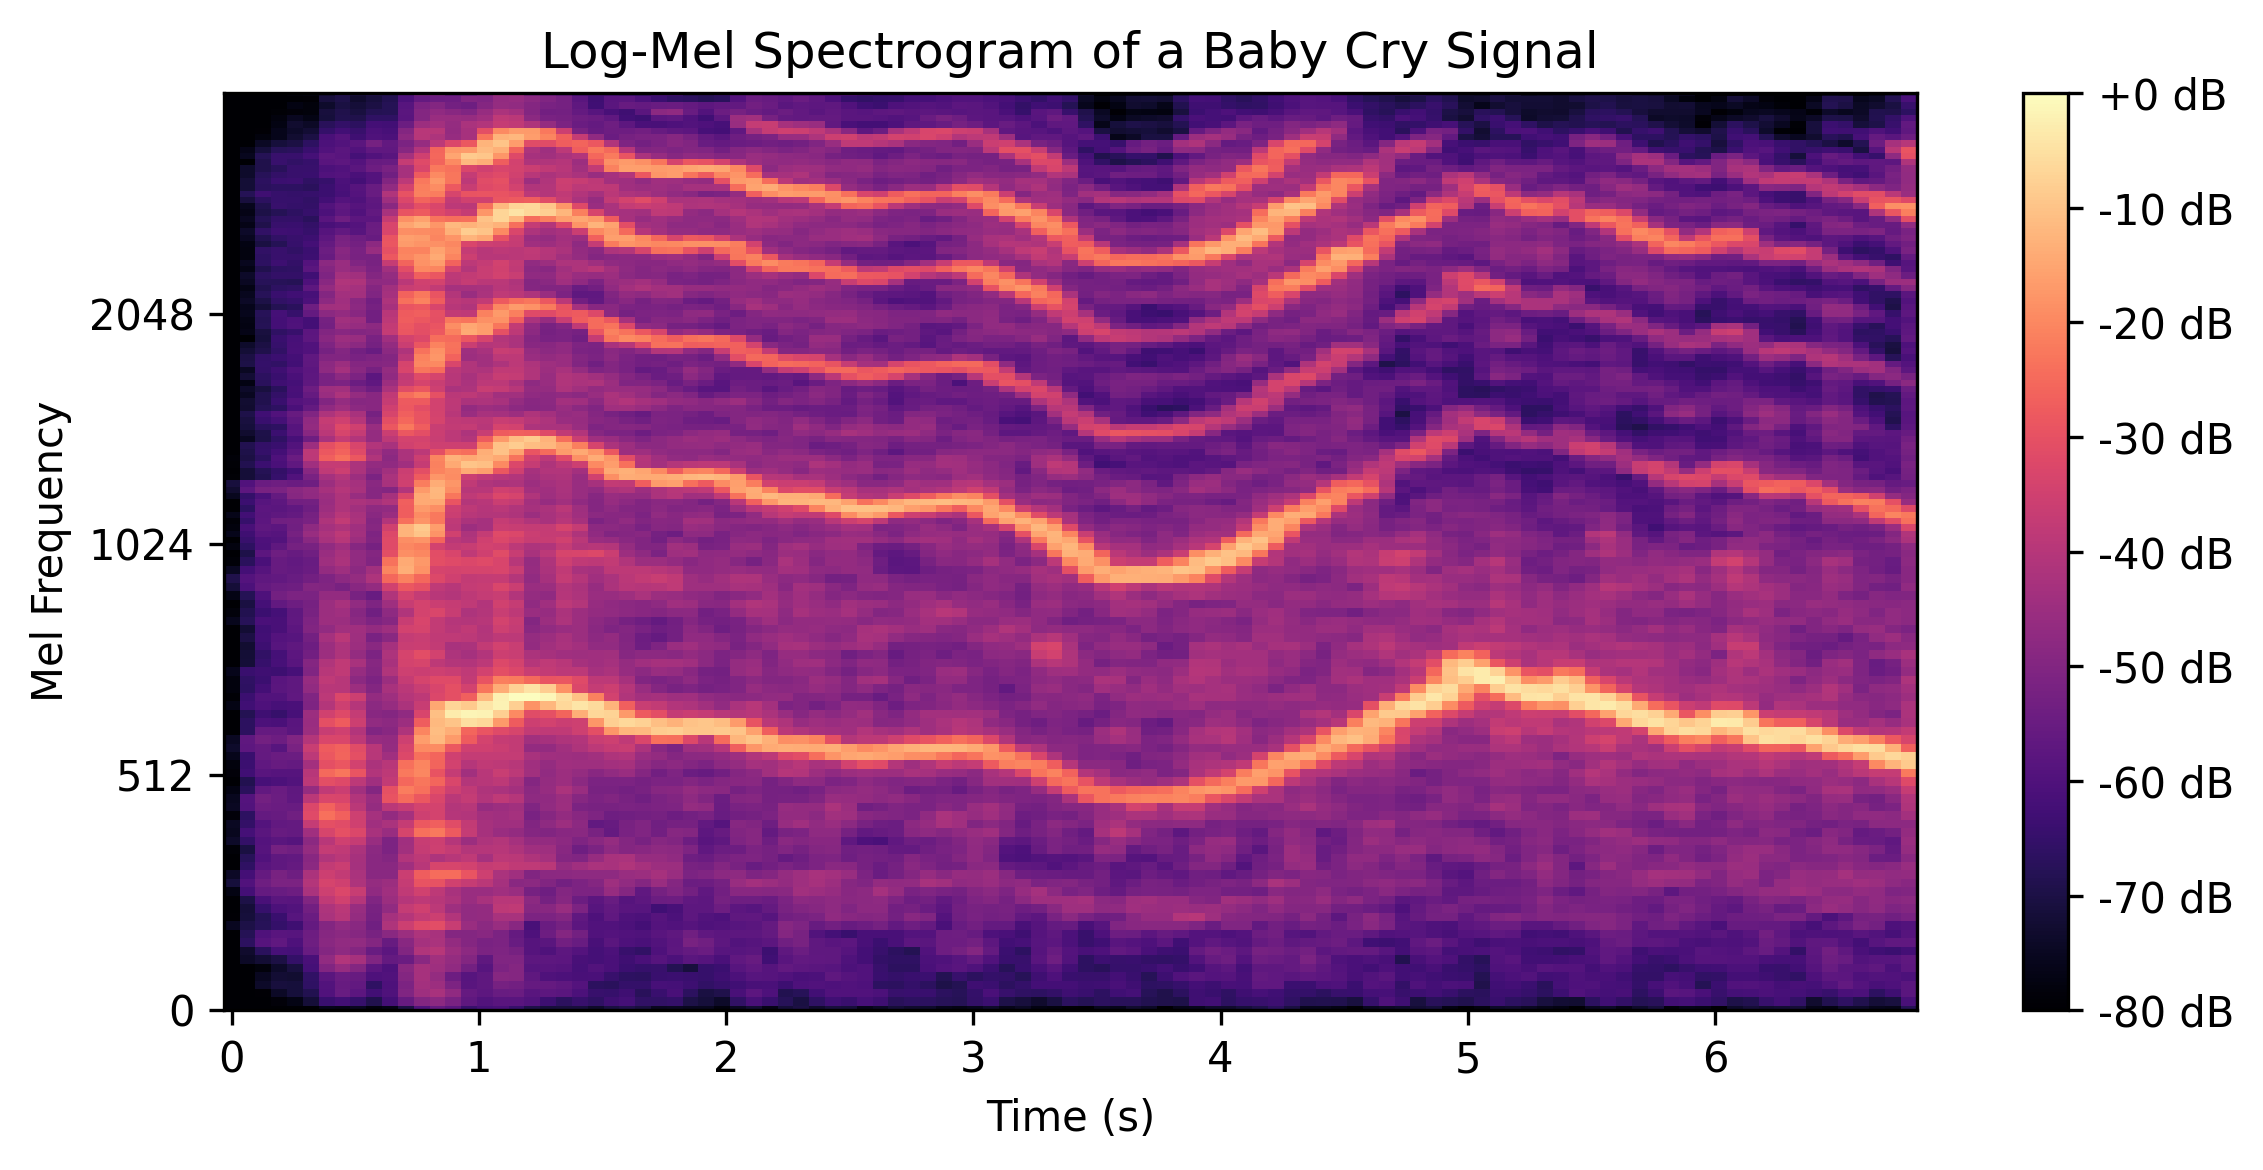

In [17]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ---- Select a clear sample (prefer "hungry") ----
audio_file = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds/hungry/0a983cd2-0078-4698-a048-99ac01eb167a-1433917038889-1.7-f-04-hu.wav"

# ---- Load audio ----
y, sr = librosa.load(audio_file, sr=None)

# ---- Compute log-Mel spectrogram ----
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)
mel_db = librosa.power_to_db(mel, ref=np.max)

# ---- Plot (publication quality) ----
plt.figure(figsize=(8, 4), dpi=300)

img = librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel',
    cmap='magma'   # good contrast, print-friendly
)

plt.colorbar(img, format='%+2.0f dB')
plt.title("Log-Mel Spectrogram of a Baby Cry Signal")
plt.xlabel("Time (s)")
plt.ylabel("Mel Frequency")

# Optional: limit to clearer band
plt.ylim(0, 4000)

plt.tight_layout()

# ---- Save for paper ----
plt.savefig("log_mel_spectrogram.png", dpi=300, bbox_inches='tight')
plt.show()